## ***Import*** dataset directly from kaggle website

In [ ]:
import kagglehub
path = kagglehub.dataset_download("apollo2506/eurosat-dataset")
print("Path to dataset files:", path)


100%|██████████| 2.04G/2.04G [00:22<00:00, 96.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/apollo2506/eurosat-dataset/versions/6


In [ ]:
import os

os.listdir(path)


['EuroSAT', 'EuroSATallBands']

In [ ]:
dataset_path = os.path.join(path, "EuroSAT")

In [ ]:
import os
print(os.listdir(dataset_path))

['Residential', 'Highway', 'train.csv', 'AnnualCrop', 'Industrial', 'Forest', 'test.csv', 'Pasture', 'HerbaceousVegetation', 'SeaLake', 'River', 'label_map.json', 'validation.csv', 'PermanentCrop']


## Import all libraries

In [ ]:
# Basic Libraries
import os
import random

# Image Handling & Visualization
from PIL import Image
import matplotlib.pyplot as plt

# TensorFlow / Keras for CNN
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Rescaling
from tensorflow.keras.preprocessing import image_dataset_from_directory

# Optional: Evaluation & preprocessing
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Optional: Data Augmentation
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom


In [ ]:
classes = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]
print("Classes found:", classes)


Classes found: ['Residential', 'Highway', 'AnnualCrop', 'Industrial', 'Forest', 'Pasture', 'HerbaceousVegetation', 'SeaLake', 'River', 'PermanentCrop']


## Display 1 Sample Image per Class

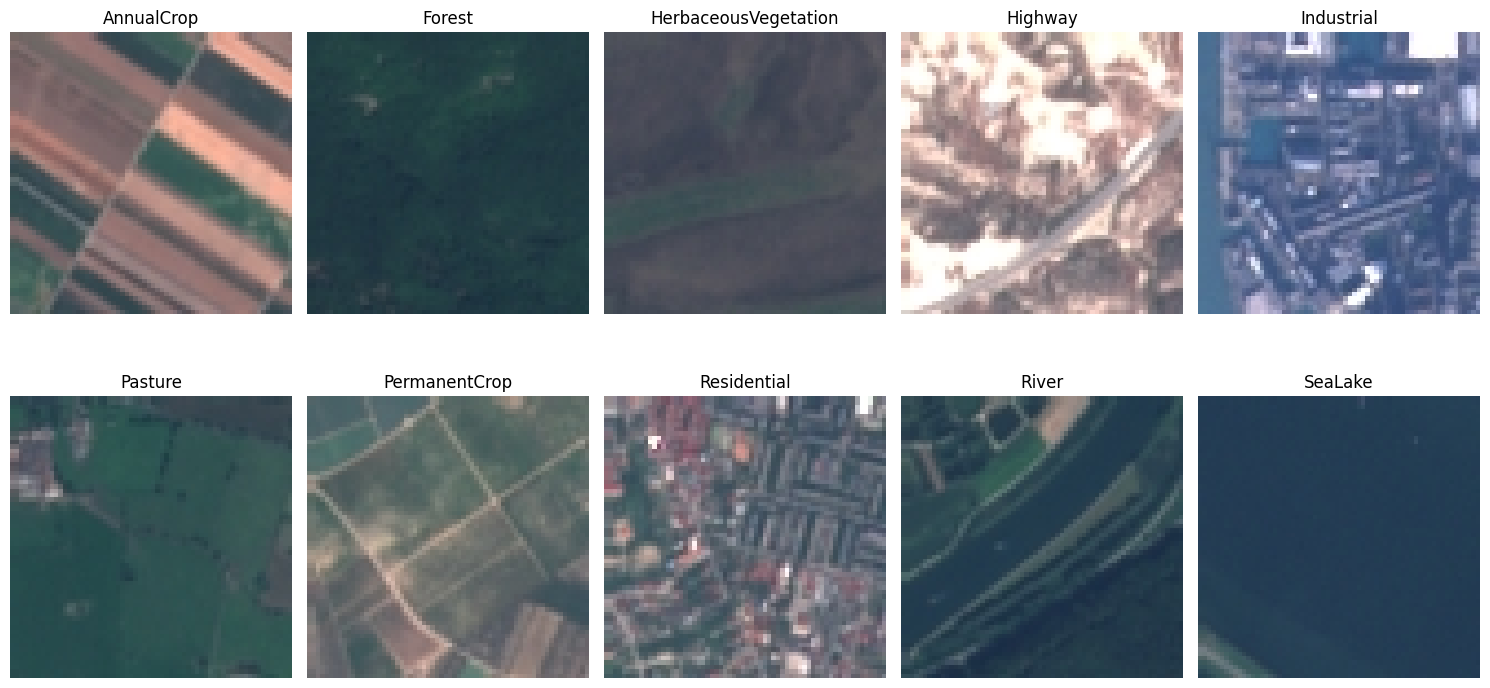

In [ ]:
plt.figure(figsize=(15,8))

for i, class_name in enumerate(classes):
    class_path = os.path.join(dataset_path, class_name)
    img_name = random.choice(os.listdir(class_path))
    img = Image.open(os.path.join(class_path, img_name))

    plt.subplot(2, 5, i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')

plt.tight_layout()
plt.show()


## Sample Image for single class

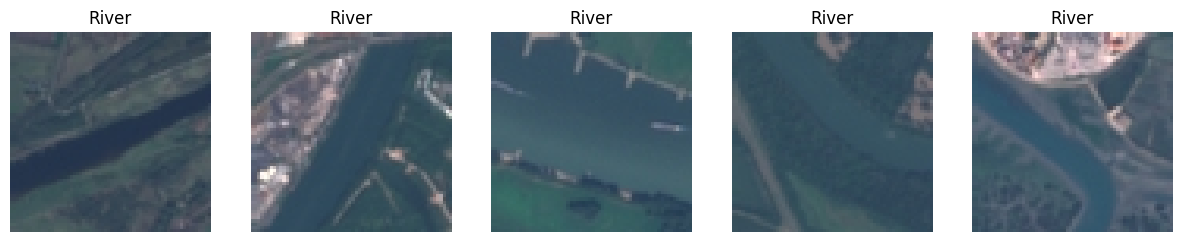

In [ ]:
class_name = "River"  # Change to any class
class_path = os.path.join(dataset_path, class_name)
sample_images = random.sample(os.listdir(class_path), 5)

plt.figure(figsize=(15,5))
for i, img_name in enumerate(sample_images):
    img = Image.open(os.path.join(class_path, img_name))
    plt.subplot(1, 5, i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')
plt.show()


## **Preprocessing**

- Resize & Normalize

- Resize all images to 64x64 pixels (you can adjust later)

- Normalize pixel values to 0–1 for better CNN performance

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.utils import class_weight
import numpy as np
import os

# --- Dataset settings ---
# The correct dataset_path was already determined from the Kaggle download.
# We need to make sure to use that path here.
path = '/root/.cache/kagglehub/datasets/apollo2506/eurosat-dataset/versions/6'
dataset_path = os.path.join(path, "EuroSAT")
IMG_SIZE = (64, 64)
BATCH_SIZE = 32
SEED = 123

# --- Load datasets ---
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# --- Class names & check for imbalance ---
classes = train_ds.class_names
print("Classes:", classes)
class_counts = {c: len(os.listdir(os.path.join(dataset_path, c))) for c in classes}
print("Class counts:", class_counts)

# --- Compute class weights ---
train_labels = np.concatenate([y.numpy() for x, y in train_ds], axis=0)
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights_dict = dict(enumerate(class_weights))
print("Class weights:", class_weights_dict)

Found 27000 files belonging to 10 classes.
Using 21600 files for training.
Found 27000 files belonging to 10 classes.
Using 5400 files for validation.
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Class counts: {'AnnualCrop': 3000, 'Forest': 3000, 'HerbaceousVegetation': 3000, 'Highway': 2500, 'Industrial': 2500, 'Pasture': 2000, 'PermanentCrop': 2500, 'Residential': 3000, 'River': 2500, 'SeaLake': 3000}
Class weights: {0: np.float64(0.8848832445718967), 1: np.float64(0.9052808046940486), 2: np.float64(0.8958938199917047), 3: np.float64(1.0794602698650675), 4: np.float64(1.073558648111332), 5: np.float64(1.3441194772868699), 6: np.float64(1.095890410958904), 7: np.float64(0.9140922556072789), 8: np.float64(1.0751617720258835), 9: np.float64(0.9003751563151313)}


## **Data Augmentation**
- Increases dataset variety

- Reduces overfitting

- Helps CNN generalize better

In [ ]:
from tensorflow.keras import layers

# --- Data augmentation ---
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1)
])


## **Build CNN Model**
This pipeline:

- Handles class imbalance automatically via class_weight.

- Uses 3 Conv layers + dropout to improve feature extraction & reduce overfitting.

- Keeps data augmentation inside the model to make training more robust.

##CNN Model
- CNNs are perfect for image classification

- They automatically extract features like edges, shapes, and textures

- Works well for land-use classification in satellite images

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Rescaling
from tensorflow.keras.layers import Input

model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(64, 64, 3)),
    data_augmentation,

    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(classes), activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [77]:
model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,879,328 (18.61 MB)

 Trainable params: 1,626,442 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,252,886 (12.41 MB)

## **Train the CNN**

In [58]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    class_weight=class_weights_dict
)
# --- Evaluate ---
loss, acc = model.evaluate(val_ds)
print("Validation Accuracy:", acc)

Epoch 1/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 208s 308ms/step - accuracy: 0.4078 - loss: 1.5014 - val_accuracy: 0.4976 - val_loss: 1.3877
Epoch 2/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 189s 280ms/step - accuracy: 0.6155 - loss: 1.0873 - val_accuracy: 0.7089 - val_loss: 0.8371
Epoch 3/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 191s 264ms/step - accuracy: 0.6748 - loss: 0.9316 - val_accuracy: 0.7156 - val_loss: 0.7731
Epoch 4/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 179s 265ms/step - accuracy: 0.7133 - loss: 0.8237 - val_accuracy: 0.6830 - val_loss: 0.8419
Epoch 5/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 180s 266ms/step - accuracy: 0.7266 - loss: 0.7864 - val_accuracy: 0.7370 - val_loss: 0.7291
Epoch 6/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 178s 264ms/step - accuracy: 0.7505 - loss: 0.7292 - val_accuracy: 0.7654 - val_loss: 0.6504
Epoch 7/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 178s 263ms/step - accuracy: 0.7603 - loss: 0.6998 - val_accuracy: 0.7894 - val_loss: 0.5714
Epoch 8/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 188s 279ms/step - accuracy: 0.7852 -

## **Plot Accuracy & Loss Graphs**

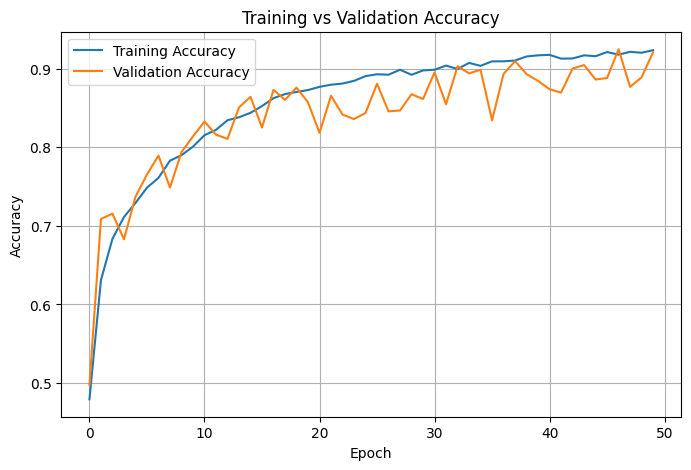

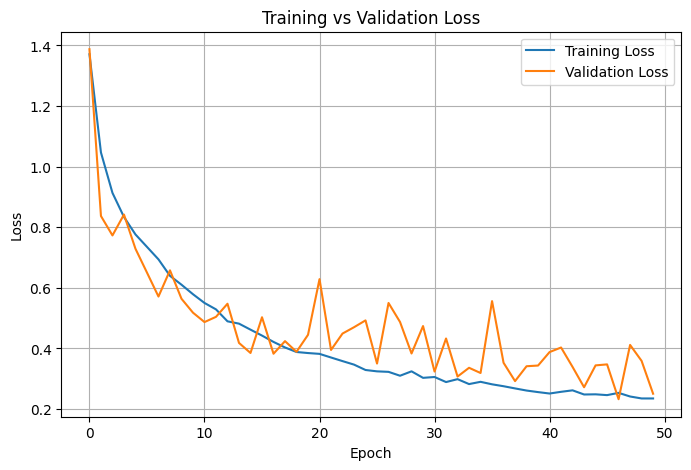

In [61]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss plot
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()


## **Confusion Matrix for Evaluation**

169/169 ━━━━━━━━━━━━━━━━━━━━ 16s 93ms/step


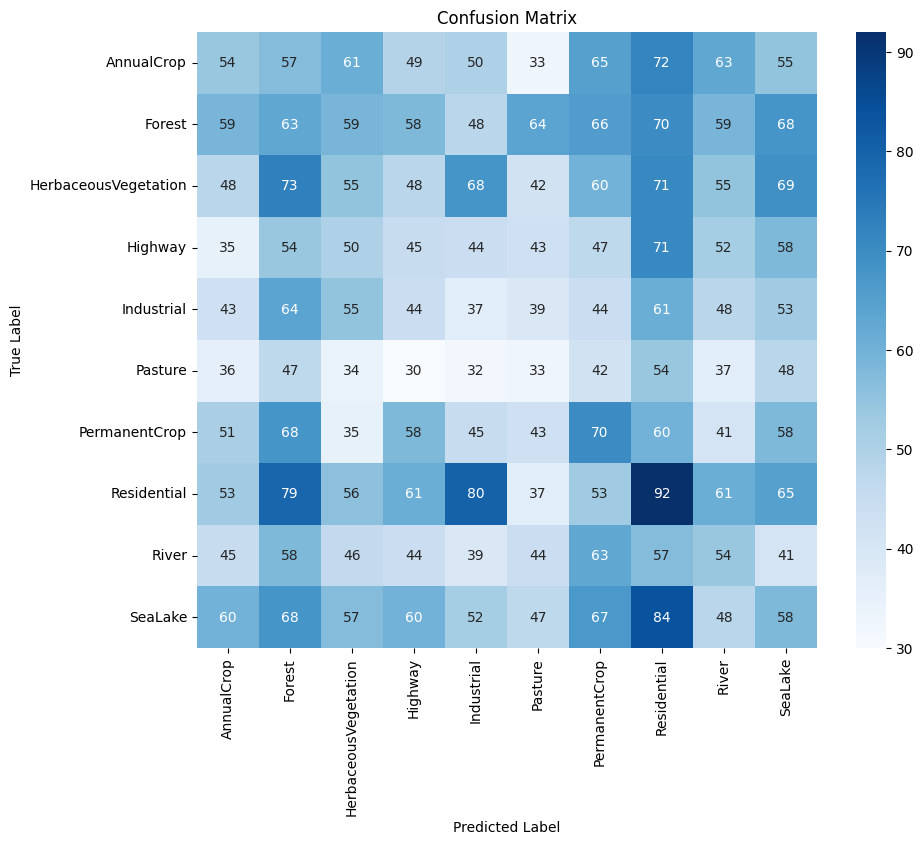

                      precision    recall  f1-score   support

          AnnualCrop       0.11      0.10      0.10       559
              Forest       0.10      0.10      0.10       614
HerbaceousVegetation       0.11      0.09      0.10       589
             Highway       0.09      0.09      0.09       499
          Industrial       0.07      0.08      0.08       488
             Pasture       0.08      0.08      0.08       393
       PermanentCrop       0.12      0.13      0.13       529
         Residential       0.13      0.14      0.14       637
               River       0.10      0.11      0.11       491
             SeaLake       0.10      0.10      0.10       601

            accuracy                           0.10      5400
           macro avg       0.10      0.10      0.10      5400
        weighted avg       0.10      0.10      0.10      5400



In [62]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Get true labels and predictions
y_true = np.concatenate([y for x, y in val_ds], axis=0)
y_pred_probs = model.predict(val_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=classes,
            yticklabels=classes,
            cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print(classification_report(y_true, y_pred, target_names=classes))


## Testing
Pick Random Images from Dataset For Testing
- Preprocess Image for CNN
- Make Prediction
- Show confidence

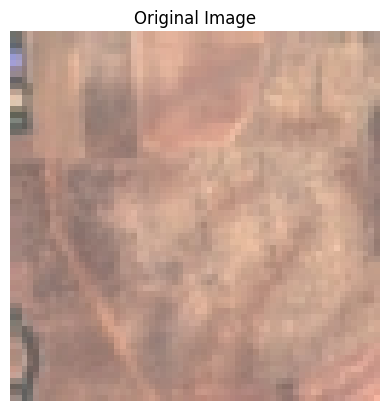

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
Predicted Class: AnnualCrop
Prediction Confidence: 100.00%


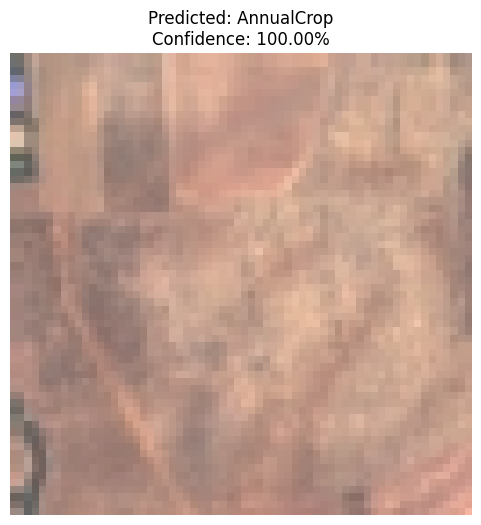

In [64]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os
from tensorflow.keras.preprocessing import image

# ----------------------------
# Pick a random class
class_name = np.random.choice(classes)   # uses existing 'classes'
class_path = os.path.join(dataset_path, class_name)

# Pick a random image from that class
img_name = np.random.choice(os.listdir(class_path))
img_path = os.path.join(class_path, img_name)

# ----------------------------
# Open and display original image
img = Image.open(img_path)
plt.imshow(img)
plt.title("Original Image")
plt.axis('off')
plt.show()

# ----------------------------
# Preprocess image for CNN
IMG_SIZE = (64, 64)
img_resized = img.resize(IMG_SIZE)

img_array = image.img_to_array(img_resized)
img_array = np.expand_dims(img_array, axis=0)   # Add batch dimension
img_array = img_array / 255.0                   # Normalize

# ----------------------------
# Make prediction
pred_prob = model.predict(img_array)
pred_class_index = np.argmax(pred_prob, axis=1)[0]
predicted_label = classes[pred_class_index]
confidence = pred_prob[0][pred_class_index] * 100

# ----------------------------
# Print results
print(f"Predicted Class: {predicted_label}")
print(f"Prediction Confidence: {confidence:.2f}%")

# ----------------------------
# Display image with prediction
plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title(f"Predicted: {predicted_label}\nConfidence: {confidence:.2f}%")
plt.axis('off')
plt.show()


## Showing the top 3 predictions with confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
Top 3 Predictions:
AnnualCrop: 100.00%
HerbaceousVegetation: 0.00%
River: 0.00%


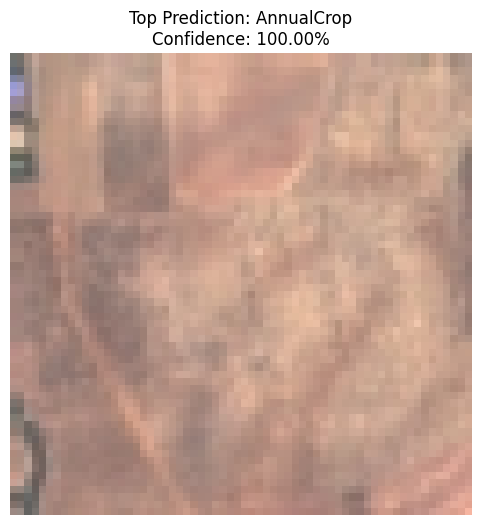

In [65]:
# ----------------------------
# Predict probabilities
pred_prob = model.predict(img_array)[0]   # Shape: (num_classes,)

# ----------------------------
# Get top 3 predictions
top3_idx = np.argsort(pred_prob)[-3:][::-1]   # Indices of top 3 classes
top3_classes = [classes[i] for i in top3_idx]
top3_confidence = [pred_prob[i] * 100 for i in top3_idx]

# ----------------------------
# Print top 3 predictions
print("Top 3 Predictions:")
for cls, conf in zip(top3_classes, top3_confidence):
    print(f"{cls}: {conf:.2f}%")

# ----------------------------
# Display image with highest confidence prediction
plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title(f"Top Prediction: {top3_classes[0]}\nConfidence: {top3_confidence[0]:.2f}%")
plt.axis('off')
plt.show()


## Test Multiple Images at Once

-  ***Prediction form differnt classes***

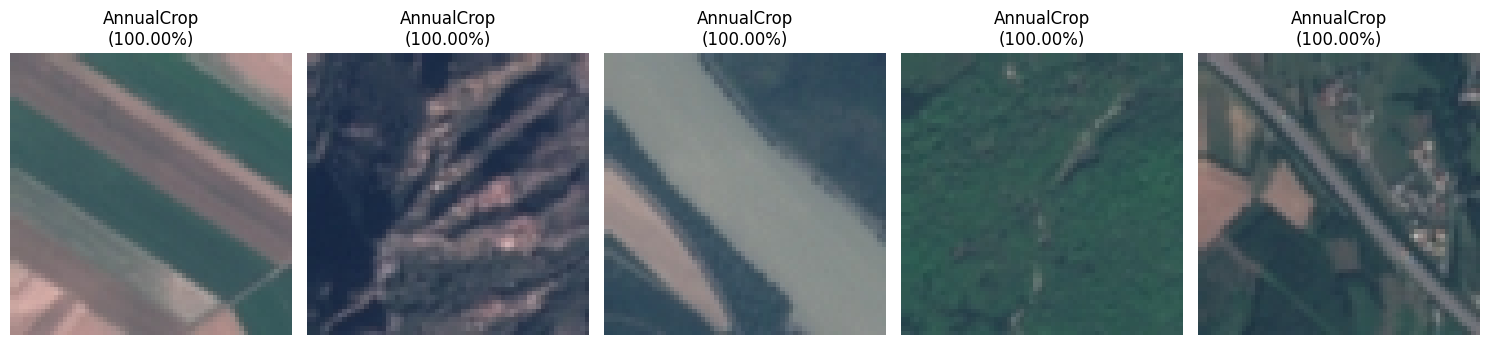

In [66]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from tensorflow.keras.preprocessing import image
import os
import random

# Number of random images to test
num_images = 5
IMG_SIZE = (64, 64)

# Prepare figure
plt.figure(figsize=(15,5))

# Pick random classes
sample_classes = random.sample(classes, num_images)

for i, class_name in enumerate(sample_classes):

    # Pick a random image from the class
    class_path = os.path.join(dataset_path, class_name)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    # Load image and ensure RGB
    img = Image.open(img_path).convert("RGB")

    # Preprocess image
    img_array = image.img_to_array(img.resize(IMG_SIZE))
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0

    # Predict
    pred_prob = model.predict(img_array, verbose=0)[0]
    pred_class_idx = np.argmax(pred_prob)
    predicted_label = classes[pred_class_idx]
    confidence = pred_prob[pred_class_idx] * 100

    # Plot result
    plt.subplot(1, num_images, i+1)
    plt.imshow(img)
    plt.title(f"{predicted_label}\n({confidence:.2f}%)")
    plt.axis('off')

plt.tight_layout()
plt.show()


##TOP-3 PREDICTIONS FOR EACH IMAGE

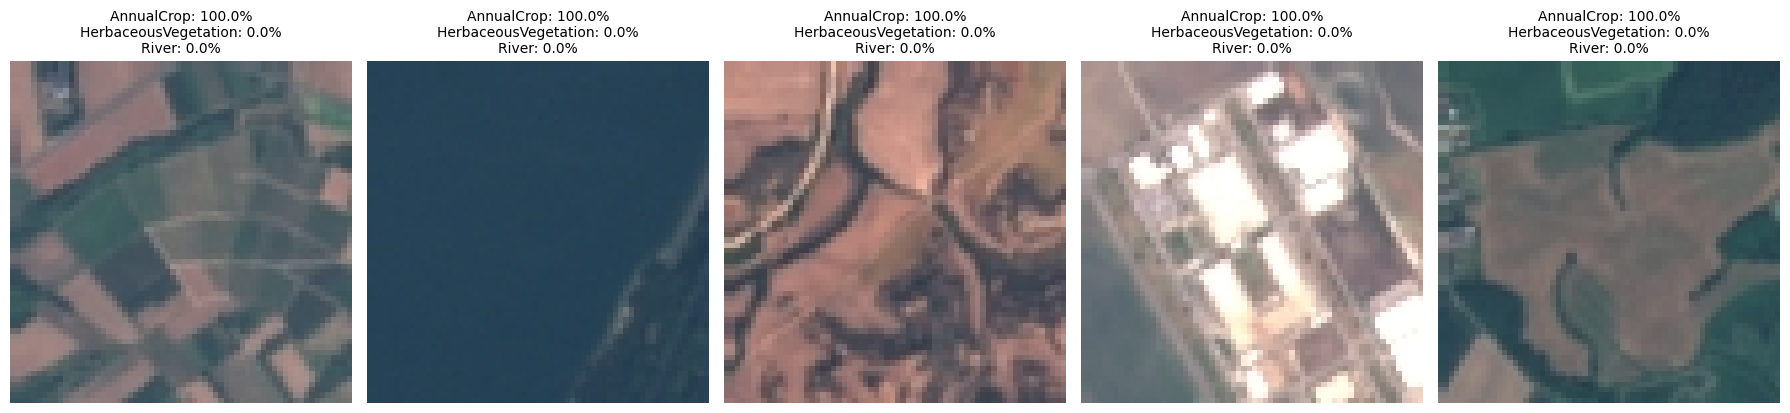

In [67]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from tensorflow.keras.preprocessing import image
import os
import random

num_images = 5
IMG_SIZE = (64, 64)

plt.figure(figsize=(18,6))

sample_classes = random.sample(classes, num_images)

for i, class_name in enumerate(sample_classes):

    class_path = os.path.join(dataset_path, class_name)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path).convert("RGB")

    img_array = image.img_to_array(img.resize(IMG_SIZE))
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # Predict probabilities
    pred_prob = model.predict(img_array, verbose=0)[0]

    # Top-3 predictions
    top3_idx = np.argsort(pred_prob)[-3:][::-1]
    top3_text = "\n".join(
        [f"{classes[j]}: {pred_prob[j]*100:.1f}%" for j in top3_idx]
    )

    plt.subplot(1, num_images, i+1)
    plt.imshow(img)
    plt.title(top3_text, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()


##Saving

In [76]:
# Save model in native Keras format
model.save("eurosat_cnn_model.keras")

 ***We Are Using Another Model (ResNet50) For comparision***

## Prepare ResNet50 (Transfer Learning)

Import ResNet50 from Keras:

---



In [78]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam


Setting input size

In [79]:
IMG_SIZE = (64, 64, 3)  # Small size works; can use 224x224 for standard ResNet


Load pretrained ResNet50 (without top layer)

In [80]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=IMG_SIZE)
base_model.trainable = False  # Freeze convolutional layers first


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Add Custom Classifier on Top
- Add global pooling + dense + dropout + output layer:

In [81]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(10, activation='softmax')(x)

resnet_model = Model(inputs=base_model.input, outputs=predictions)


##Compile the model

In [82]:
resnet_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


## Train ResNet50

In [84]:
resnet_model.fit(
    train_ds,8
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weights_dict # Changed from class_weights to class_weights_dict
)

Epoch 1/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 408s 592ms/step - accuracy: 0.5279 - loss: 1.6912 - val_accuracy: 0.8676 - val_loss: 0.4148
Epoch 2/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 400s 593ms/step - accuracy: 0.8428 - loss: 0.5041 - val_accuracy: 0.8900 - val_loss: 0.3301
Epoch 3/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 401s 594ms/step - accuracy: 0.8811 - loss: 0.3848 - val_accuracy: 0.9017 - val_loss: 0.2928
Epoch 4/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 400s 593ms/step - accuracy: 0.8974 - loss: 0.3227 - val_accuracy: 0.9070 - val_loss: 0.2793
Epoch 5/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 398s 590ms/step - accuracy: 0.9076 - loss: 0.2843 - val_accuracy: 0.9174 - val_loss: 0.2557
Epoch 6/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 400s 593ms/step - accuracy: 0.9169 - loss: 0.2571 - val_accuracy: 0.9178 - val_loss: 0.2512
Epoch 7/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 399s 592ms/step - accuracy: 0.9258 - loss: 0.2332 - val_accuracy: 0.9215 - val_loss: 0.2392
Epoch 8/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 438s 585ms/step - accuracy: 0.9300 -

##Evaluate Both Models

In [85]:
from sklearn.metrics import confusion_matrix, classification_report
y_true = np.concatenate([y for x, y in val_ds], axis=0)
y_pred = np.argmax(resnet_model.predict(val_ds), axis=1)
print(classification_report(y_true, y_pred, target_names=classes))


169/169 ━━━━━━━━━━━━━━━━━━━━ 100s 522ms/step
                      precision    recall  f1-score   support

          AnnualCrop       0.11      0.12      0.12       559
              Forest       0.10      0.10      0.10       614
HerbaceousVegetation       0.12      0.13      0.12       589
             Highway       0.12      0.12      0.12       499
          Industrial       0.09      0.10      0.10       488
             Pasture       0.07      0.07      0.07       393
       PermanentCrop       0.12      0.11      0.12       529
         Residential       0.13      0.13      0.13       637
               River       0.09      0.09      0.09       491
             SeaLake       0.12      0.12      0.12       601

            accuracy                           0.11      5400
           macro avg       0.11      0.11      0.11      5400
        weighted avg       0.11      0.11      0.11      5400



##Plot Accuracy Comparison

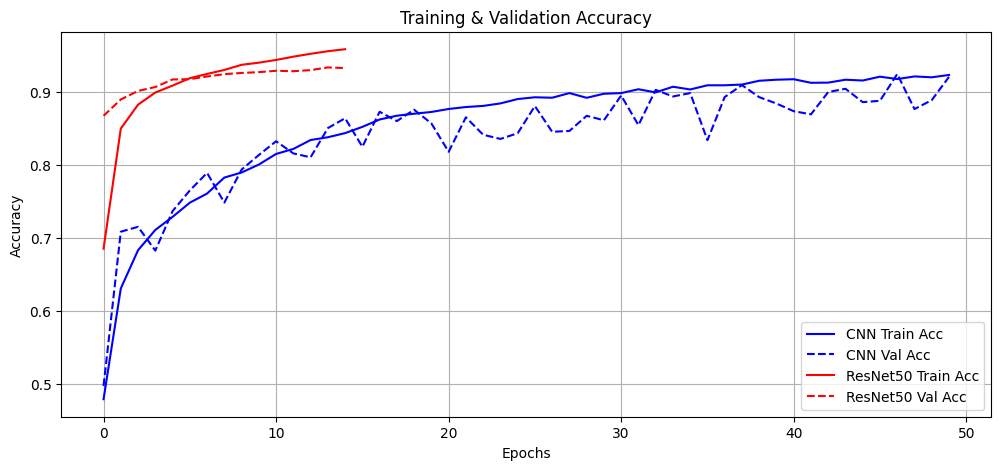

In [87]:
import matplotlib.pyplot as plt

# Assuming 'history' is the training history for the CNN model
# and 'resnet_history' is the training history for the ResNet50 model

plt.figure(figsize=(12,5))

# Plot Training Accuracy
plt.plot(history.history['accuracy'], label='CNN Train Acc', color='blue')
plt.plot(history.history['val_accuracy'], label='CNN Val Acc', color='blue', linestyle='--')

plt.plot(resnet_model.history.history['accuracy'], label='ResNet50 Train Acc', color='red')
plt.plot(resnet_model.history.history['val_accuracy'], label='ResNet50 Val Acc', color='red', linestyle='--')

plt.title('Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

##Plot Loss Comparison

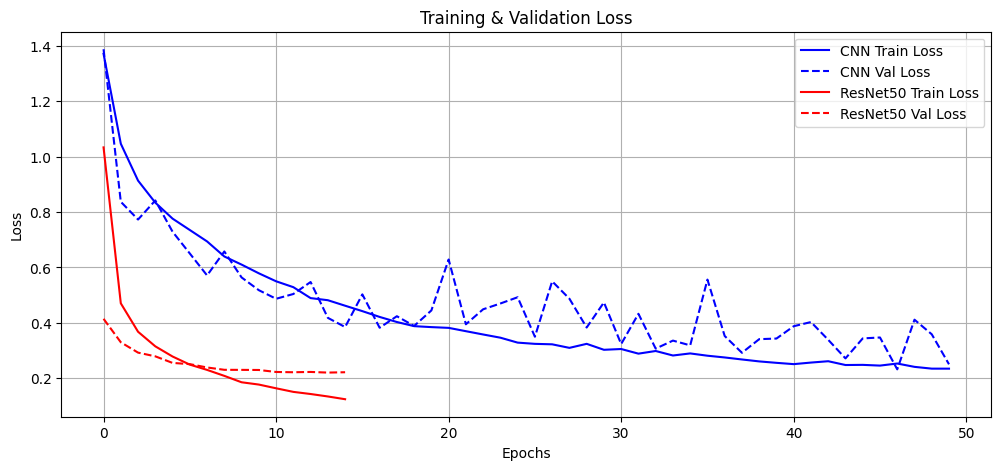

In [89]:
plt.figure(figsize=(12,5))

# Plot Training Loss
plt.plot(history.history['loss'], label='CNN Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='CNN Val Loss', color='blue', linestyle='--')

plt.plot(resnet_model.history.history['loss'], label='ResNet50 Train Loss', color='red')
plt.plot(resnet_model.history.history['val_loss'], label='ResNet50 Val Loss', color='red', linestyle='--')

plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


## Test unseen images with top-3 predictions Using (ResNet50)

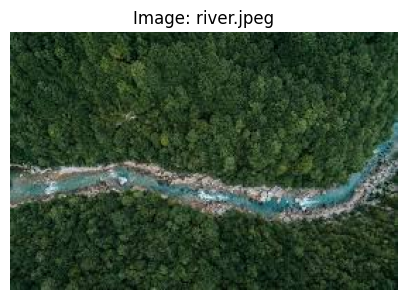


Top-3 Predictions for river.jpeg:
  SeaLake: 99.73%
  HerbaceousVegetation: 0.19%
  Forest: 0.04%


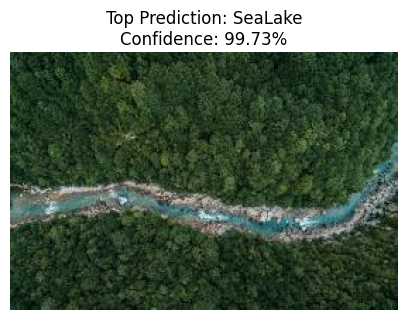

In [97]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from tensorflow.keras.preprocessing import image
import os
import random

# Path to unseen images
unseen_folder = "/content/unseen_images"

# List all image files in the folder
img_files = [f for f in os.listdir(unseen_folder) if os.path.isfile(os.path.join(unseen_folder, f))]

if not img_files:
    print("No images found in the folder. Please add some images.")
else:
    # Pick a random image
    img_name = random.choice(img_files)
    img_path = os.path.join(unseen_folder, img_name)

    # Load and display original image
    img = Image.open(img_path).convert("RGB")
    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Image: {img_name}")
    plt.show()

    # Preprocess for model
    IMG_SIZE = (224, 224)  # Same as training
    img_array = image.img_to_array(img.resize(IMG_SIZE))
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # Predict probabilities using ResNet50
    pred_prob = resnet_model.predict(img_array, verbose=0)[0]

    # Top-3 predictions
    top3_idx = pred_prob.argsort()[-3:][::-1]
    top3_classes = [classes[i] for i in top3_idx]
    top3_confidence = [pred_prob[i]*100 for i in top3_idx]

    print(f"\nTop-3 Predictions for {img_name}:")
    for cls, conf in zip(top3_classes, top3_confidence):
        print(f"  {cls}: {conf:.2f}%")

    # Display image with top prediction
    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Top Prediction: {top3_classes[0]}\nConfidence: {top3_confidence[0]:.2f}%")
    plt.show()


## confusion matrix

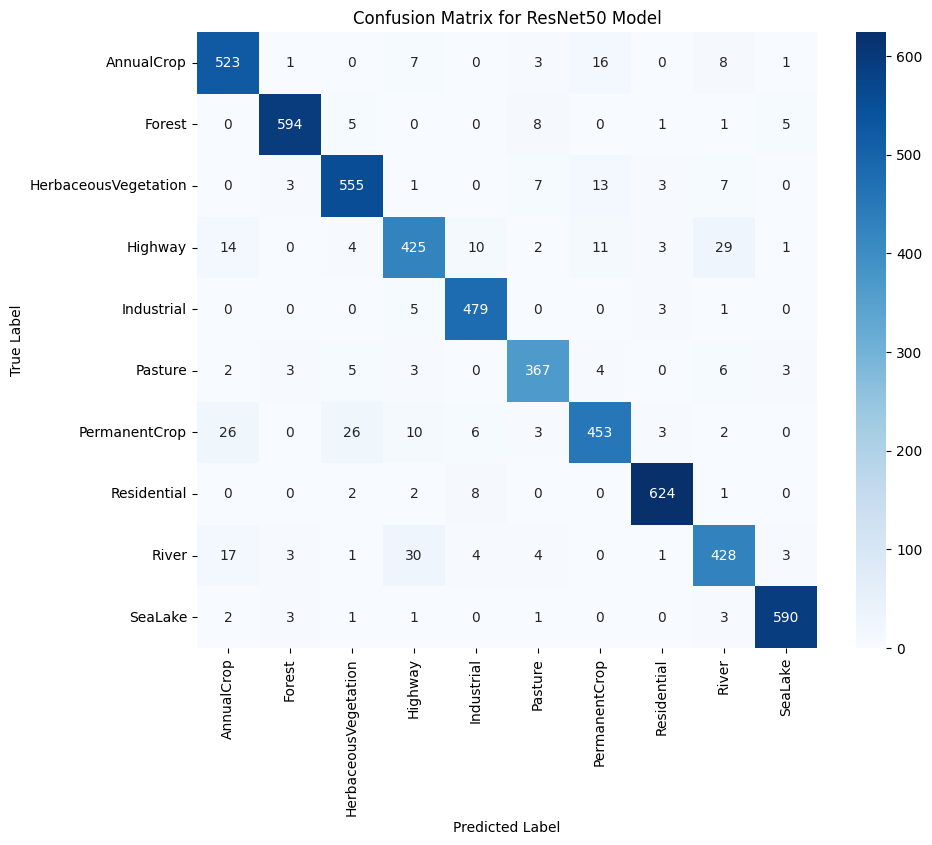

In [99]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get true labels and predictions for ResNet50 model
# Iterate over the validation dataset once to get both features and labels
all_labels = []
all_predictions = []

for images, labels in val_ds:
    all_labels.append(labels.numpy())
    # ResNet50 model was trained with IMG_SIZE (64,64,3), ensure prediction input matches.
    # The IMG_SIZE variable here is (224,224) from a later cell, which is incorrect for this model.
    # Let's verify the model's input shape or resize accordingly if needed.
    # Assuming resnet_model expects (64,64,3) as defined earlier during its setup.
    preds = resnet_model.predict(images, verbose=0)
    all_predictions.append(preds)

y_true_resnet = np.concatenate(all_labels, axis=0)
y_pred_resnet = np.argmax(np.concatenate(all_predictions, axis=0), axis=1)

# Confusion Matrix for ResNet50
cm_resnet = confusion_matrix(y_true_resnet, y_pred_resnet)

plt.figure(figsize=(10,8))
sns.heatmap(cm_resnet, annot=True, fmt='d',
            xticklabels=classes,
            yticklabels=classes,
            cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for ResNet50 Model')
plt.show()